# 10_06 What if stores ordered on quantiles? A newsvendor simulation with real prices

**The question, in plain words.** `10_05` showed that about a quarter of every
demand surprise ends up as physical surplus in the stores, and the first version
of this notebook mapped the leftover-vs-unmet trade-off **in kilograms**, leaving
the cost ratio — *how bad is a leftover kg compared to a lost sale?* — as a free
parameter for the business. That parameter is no longer free. The new
`data/raw/artikel_preis` extract carries, for every article × region × validity
window, two prices per kilogram:

- **`ESP_KALK`** — the calculatory purchase price (net €/kg). This is not a
  guess: the goods-movement ledger values internal counter bookings at exactly
  this price (88.7% of bookings within 1%), so it is the number the ERP itself
  treats as the marginal cost of one kg of counter product.
- **`BRUTTOPREIS_EH`** — the gross shelf price (€/kg). It matches the realized
  checkout price per kg in the transactions to within 0.1% at the median.

With both, the two error costs of every order line become data:

- **leftover kg** costs `c_o = ESP` — the money spent on meat nobody bought
  (salvage value zero for fresh counter goods);
- **unmet kg** costs `c_u = BRUTTOPREIS/1.07 − ESP` — the net margin the sale
  would have earned (7% food VAT removed; purchase prices are already net).

The classic **newsvendor rule** then says: order the quantile
`τ* = c_u / (c_u + c_o) = 1 − ESP / net price` of the predicted demand
distribution — a number this notebook can compute **per article**, instead of
offering a menu. The simulation below asks, for all order lines of the 20
evaluation weeks: what would each uniform quantile rule have cost in euros, what
does the point forecast cost, and what does the per-article newsvendor rule cost?

**Mechanics kept from v1** (see `10_02`/`10_04` for the corridors): orders are
read off each row's predictive distribution (occurrence probability ×
P10/P50/P90 corridor, piecewise linear). Two scoring grains bracket shelf-life
reality: per day (no carry-over, upper bound) and per week (full within-week
carry-over, lower bound). Prices are joined per (article, region, day); the few
same-day multi-delivery-size entries are averaged, and the one placeholder-priced
article is imputed at the median cost share. Raw corridors are used; the
conformal stretch of `10_04` (~2% wider) would not visibly move these curves.

**A note on the word "order".** Most articles here are pseudo articles: they are
not ordered from a supplier but made at the counter. The store orders whole cuts
of meat; each morning the staff decides how much of them to turn into counter
products — for example, *"grind 10 kg of Hackfleisch today"*. That morning
decision carries exactly the two risks this notebook prices: grind too much and
the unsold rest loses its value, grind too little and customers find an empty
counter. So wherever this notebook says "order 10 kg for Monday", read "produce
and display 10 kg on Monday" — the mathematics is identical. Only for the 29 FCM
articles is "order" meant literally.

In [1]:
from pathlib import Path
import sys

import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'src').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.models.benchmark import load_benchmark_design
from src.models.lightgbm import TWO_STAGE_QUANTILE_MODEL_NAME
from src.models.results import result_path

pd.set_option('display.max_columns', 40)

INK, INK2, MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, BASELINE, SURFACE = '#e1e0d9', '#c3c2b7', '#fcfcfb'
BLUE, ORANGE, AQUA, GRAY = '#2a78d6', '#eb6834', '#1baf7a', '#c3c2b7'
plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': BASELINE, 'axes.labelcolor': INK2, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED, 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
})


def style_ax(ax, ygrid=True, xgrid=False):
    for side in ('top', 'right', 'left'):
        ax.spines[side].set_visible(False)
    ax.spines['bottom'].set_color(BASELINE)
    if ygrid:
        ax.grid(axis='y', color=GRID, linewidth=0.8)
    if xgrid:
        ax.grid(axis='x', color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)


design = load_benchmark_design()
con = duckdb.connect()
con.execute('PRAGMA threads=4')

rows = con.execute('''
    SELECT ARTIKEL_ID::BIGINT AS ARTIKEL_ID, MARKT_ID::BIGINT AS MARKT_ID,
           CAST(origin AS DATE) AS origin, CAST(period AS DATE) AS period,
           actual::DOUBLE AS actual, forecast::DOUBLE AS forecast,
           occurrence_probability::DOUBLE AS p_occ,
           positive_quantity_p10::DOUBLE AS p10,
           positive_quantity_p50::DOUBLE AS p50,
           positive_quantity_p90::DOUBLE AS p90
    FROM read_csv_auto(?) WHERE is_active
''', [str(result_path(TWO_STAGE_QUANTILE_MODEL_NAME, design))]).fetchdf()

VAT = 1.07  # German reduced VAT on food; ESP_KALK is net, BRUTTOPREIS_EH gross
PRICE_FILE = ROOT / 'data' / 'raw' / 'artikel_preis' / 'artikel_preis_wgr_890_900.csv'
con.register('lines', rows[['ARTIKEL_ID', 'MARKT_ID', 'period']].drop_duplicates())
prices = con.execute('''
    SELECT l.ARTIKEL_ID, l.MARKT_ID, l.period,
           AVG(p.ESP_KALK) AS esp, AVG(p.BRUTTOPREIS_EH) AS brutto
    FROM lines l
    JOIN read_csv_auto(?) p
      ON p.ARTIKEL_ID = l.ARTIKEL_ID
     AND p.MANDANT_ID = l.MARKT_ID // 10000
     AND l.period::DATE BETWEEN p.GUELTIG_VON_ARTIKEL_PREIS
                            AND p.GUELTIG_BIS_ARTIKEL_PREIS
    WHERE p.ESP_KALK > 0.01  -- drop "price not maintained" placeholders
    GROUP BY 1, 2, 3
''', [str(PRICE_FILE)]).fetchdf()
rows = rows.merge(prices, on=['ARTIKEL_ID', 'MARKT_ID', 'period'], how='left')
matched = rows.esp.notna().mean()

# Fill the small unmatched remainder (uncovered validity days, the one
# placeholder-priced article) with the article's median price; if an article
# has no usable price at all, fall back to the assortment-median shelf price
# and cost share.
for col in ('esp', 'brutto'):
    rows[col] = rows[col].fillna(
        rows.groupby('ARTIKEL_ID')[col].transform('median'))
rows['brutto'] = rows.brutto.fillna(rows.brutto.median())
median_cost_share = (rows.esp / rows.brutto).median()
rows['esp'] = rows.esp.fillna(median_cost_share * rows.brutto)

rows['net_price'] = rows.brutto / VAT
rows['c_over'] = rows.esp                                   # leftover kg: cash cost
rows['c_under'] = (rows.net_price - rows.esp).clip(lower=0)  # unmet kg: lost margin
rows['tau_star'] = (rows.c_under / (rows.c_under + rows.c_over)).clip(0.05, 0.95)

art_tau = rows.groupby('ARTIKEL_ID').agg(
    tau_star=('tau_star', 'median'), demand_kg=('actual', 'sum'))
print(f'{len(rows):,} order lines, {rows.actual.sum():,.0f} kg demand, '
      f'{matched:.1%} matched to a same-day price')
print(f'cost share ESP/net: median {(rows.esp / rows.net_price).median():.3f}   '
      f'-> newsvendor tau* per article: '
      f'P10 {art_tau.tau_star.quantile(0.1):.2f}, '
      f'median {art_tau.tau_star.median():.2f}, '
      f'P90 {art_tau.tau_star.quantile(0.9):.2f}')

2,498,967 order lines, 2,661,595 kg demand, 100.0% matched to a same-day price
cost share ESP/net: median 0.518   -> newsvendor tau* per article: P10 0.25, median 0.44, P90 0.58


## 1 · The dial now has a computable setting

Every article's `τ*` is its margin share: a high-margin article (cheap to buy,
expensive on the shelf) *should* be ordered generously — a lost sale burns more
margin than a leftover burns cost. A low-margin article should be ordered
cautiously. The histogram shows where the assortment actually sits, weighted by
demand. Two things to note: the mass sits **below** 0.5 (fresh meat margins are
thinner than the intuitive "costs equal" default), and the spread is real —
the assortment does not agree on one quantile.

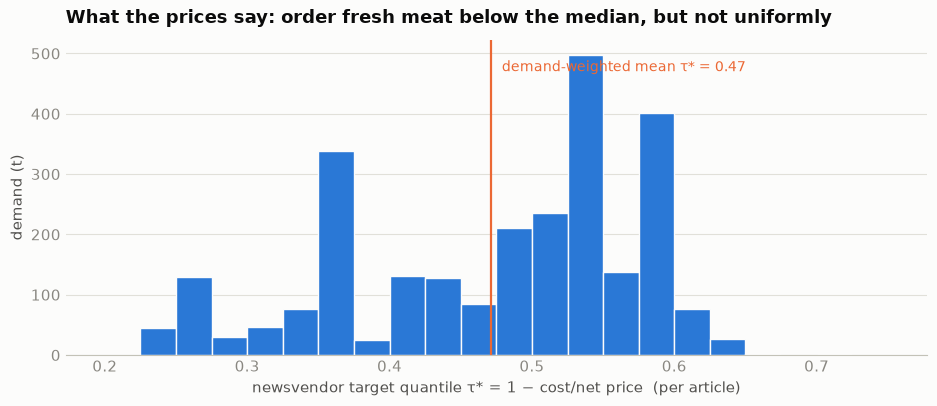

In [2]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.hist(art_tau.tau_star, bins=np.arange(0.20, 0.751, 0.025),
        weights=art_tau.demand_kg / 1000, color=BLUE, edgecolor=SURFACE)
med = np.average(art_tau.tau_star, weights=art_tau.demand_kg)
ax.axvline(med, color=ORANGE, linewidth=1.6)
ax.annotate(f'demand-weighted mean τ* = {med:.2f}', (med + 0.008, ax.get_ylim()[1] * 0.9),
            color=ORANGE, fontsize=10)
style_ax(ax)
ax.set_xlabel('newsvendor target quantile τ* = 1 − cost/net price  (per article)')
ax.set_ylabel('demand (t)')
ax.set_title('What the prices say: order fresh meat below the median, '
             'but not uniformly', pad=12)
plt.tight_layout()
plt.show()

## 2 · The euro curve

Now every policy gets a price tag instead of two kg shares. For each rule we sum
**leftover cost** (leftover kg × its article-day `ESP`) and **lost margin**
(unmet kg × its article-day margin) over all order lines, at both grains. The
uniform rules trace a U-shaped cost curve in τ; the point forecast and the
per-article newsvendor rule are horizontal benchmarks. Costs are stated in € per
100 kg of demand so the numbers stay comparable with the v1 menu.

policy,leftover_kg_week,unmet_kg_week,eur_leftover_week,eur_lost_margin_week,eur_total_week,eur_total_day
P30,2.41,44.68,14.94,247.78,262.71,313.31
P35,3.72,39.54,23.14,219.55,242.69,304.95
P40,5.56,34.67,34.66,192.85,227.51,300.82
P45,7.99,30.14,50.03,167.92,217.95,301.13
P50,11.09,25.93,69.69,144.79,214.48,306.15
P55,15.67,21.31,99.40,119.39,218.79,317.81
P60,21.50,17.24,137.30,97.03,234.33,337.48
P65,28.69,13.72,184.26,77.57,261.83,365.92
P70,37.38,10.68,241.48,60.65,302.13,404.53
P75,47.86,8.08,311.37,46.09,357.46,455.53


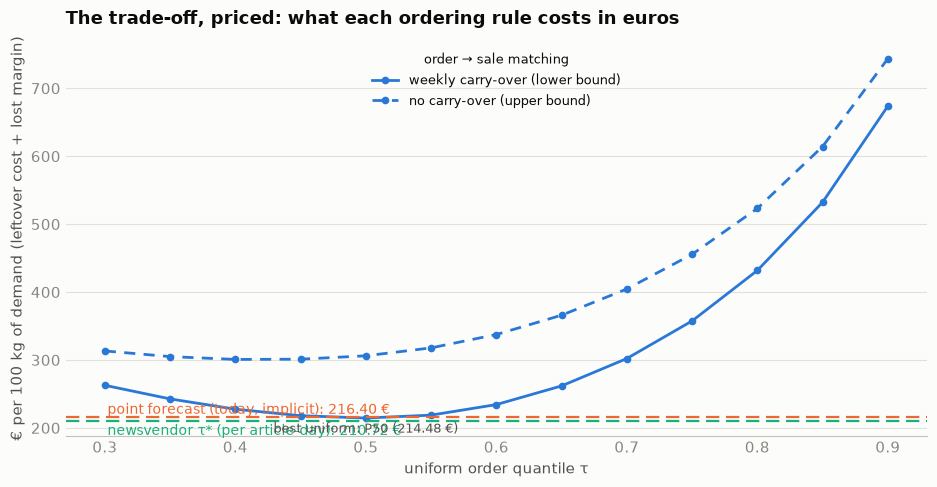

In [3]:
def order_at(tau):
    '''Order = tau-quantile of each row's predictive distribution (tau may be
    a scalar or a per-row array). Zero whenever tau <= 1 - p_occ, otherwise the
    conditional quantile at u = (tau - (1 - p_occ)) / p_occ on the piecewise-
    linear curve through (0,0), (0.1,P10), (0.5,P50), (0.9,P90), extended.'''
    p, p10, p50, p90 = (rows.p_occ.values, rows.p10.values,
                        rows.p50.values, rows.p90.values)
    u = np.clip((np.asarray(tau) - (1 - p)) / np.maximum(p, 1e-9), 0.0, 0.99)
    q = np.where(
        u <= 0.1, u / 0.1 * p10,
        np.where(u <= 0.5, p10 + (u - 0.1) / 0.4 * (p50 - p10),
                 np.where(u <= 0.9, p50 + (u - 0.5) / 0.4 * (p90 - p50),
                          p90 + (u - 0.9) / 0.4 * (p90 - p50))))
    return np.where(u <= 0, 0.0, q)


TAU_GRID = np.round(np.arange(0.30, 0.901, 0.05), 2)
POLICIES = {f'P{round(t * 100)}': order_at(t) for t in TAU_GRID}
POLICIES['point forecast (mean)'] = rows.forecast.values
POLICIES['newsvendor τ* (per article-day)'] = order_at(rows.tau_star.values)

actual = rows.actual.values
c_over, c_under = rows.c_over.values, rows.c_under.values
total_demand = actual.sum()
scale = 100 / total_demand  # -> per 100 kg of demand

week_id = rows.groupby(['ARTIKEL_ID', 'MARKT_ID', 'origin'], sort=False).ngroup().values
n_weeks = week_id.max() + 1
week_actual = np.bincount(week_id, weights=actual, minlength=n_weeks)
week_n = np.bincount(week_id, minlength=n_weeks)
week_co = np.bincount(week_id, weights=c_over, minlength=n_weeks) / week_n
week_cu = np.bincount(week_id, weights=c_under, minlength=n_weeks) / week_n

records = []
for name, order in POLICIES.items():
    over_d, short_d = np.maximum(order - actual, 0), np.maximum(actual - order, 0)
    week_order = np.bincount(week_id, weights=order, minlength=n_weeks)
    over_w = np.maximum(week_order - week_actual, 0)
    short_w = np.maximum(week_actual - week_order, 0)
    records.append({
        'policy': name,
        'leftover_kg_week': over_w.sum() * scale,
        'unmet_kg_week': short_w.sum() * scale,
        'eur_leftover_week': (over_w * week_co).sum() * scale,
        'eur_lost_margin_week': (short_w * week_cu).sum() * scale,
        'eur_total_week': ((over_w * week_co).sum() + (short_w * week_cu).sum()) * scale,
        'eur_total_day': ((over_d * c_over).sum() + (short_d * c_under).sum()) * scale,
    })
policies = pd.DataFrame(records)
display(policies.style.format({c: '{:,.2f}' for c in policies.columns[1:]})
        .hide(axis='index'))

quant = policies[policies.policy.str.startswith('P')]
mean_row = policies[policies.policy.str.startswith('point')].iloc[0]
news_row = policies[policies.policy.str.startswith('news')].iloc[0]
best_uniform = quant.loc[quant.eur_total_week.idxmin()]

fig, ax = plt.subplots(figsize=(9.5, 5))
for grain, ls, label in (('week', '-', 'weekly carry-over (lower bound)'),
                         ('day', (0, (4, 3)), 'no carry-over (upper bound)')):
    ax.plot(TAU_GRID, quant[f'eur_total_{grain}'], color=BLUE, linewidth=2,
            linestyle=ls, marker='o', markersize=4.5, label=label)
for row, color, dy, txt in (
        (mean_row, ORANGE, 1.02, 'point forecast (today, implicit)'),
        (news_row, AQUA, 0.90, 'newsvendor τ* (per article-day)')):
    ax.axhline(row.eur_total_week, color=color, linewidth=1.6,
               linestyle=(0, (6, 3)))
    ax.annotate(f'{txt}: {row.eur_total_week:.2f} €',
                (0.302, row.eur_total_week * dy), color=color, fontsize=10)
ax.annotate(f'best uniform: {best_uniform.policy} '
            f'({best_uniform.eur_total_week:.2f} €)',
            (float(best_uniform.policy[1:]) / 100, best_uniform.eur_total_week * 0.90),
            color=INK2, fontsize=9.5, ha='center')
style_ax(ax)
ax.set_xlabel('uniform order quantile τ')
ax.set_ylabel('€ per 100 kg of demand (leftover cost + lost margin)')
ax.set_title('The trade-off, priced: what each ordering rule costs in euros',
             pad=12)
ax.legend(frameon=False, fontsize=9.5, title='order → sale matching',
          title_fontsize=9.5, loc='upper center')
plt.tight_layout()
plt.show()

**Reading the euro curve.**

- **The U-bottom lands where the prices predicted it.** The cheapest uniform
  quantile is P45–P50 (218.0 / 214.5 € per 100 kg) — right between the
  assortment's median `τ*` of 0.44 and its demand-weighted mean of 0.47 from
  Section 1. The prices and the simulation
  agree with each other, which is the sanity check this design needed.
- **Today's implicit rule is accidentally near-optimal — on average.** Ordering
  the point forecast costs 216.4 €, within 1% of the best uniform quantile. So
  the headline is *not* "stores order badly"; averaged over the assortment they
  sit almost exactly at the cost minimum.
- **The per-article newsvendor still beats everything**: 210.7 € at week grain
  (−2.6% vs today, −1.8% vs the best uniform) and 291.0 € at day grain
  (−13.7% vs today's 337.1 €). The gap is small where within-week carry-over
  forgives daily errors, and large where it does not — exactly the pattern one
  expects if the value lies in *per-line targeting* rather than in a better
  global service level.
- **Note what the optimum trades away.** The newsvendor rule holds *less* stock
  than today (11.7 vs 14.9 leftover kg per 100) and misses *more* demand
  (28.6 vs 21.2 kg). The prices are blunt about it: at a median cost share of
  ~52% of the net price, the last service points cost more in leftovers than
  they earn in margin. Fill rate is not the objective; euros are.

## 3 · Where the money sits: the per-article dial in euros

The curve above scores *uniform* rules against the *per-article* newsvendor. The
gap between the best uniform quantile and `τ*` is the value of treating the
quantile as a dial rather than a policy constant. The table below splits that
gap by article: for each article, the weekly-grain euro cost under today's
implicit rule (order the mean), under the best uniform quantile, and under its
own `τ*`.

In [4]:
art_names = con.execute('''
    SELECT ARTIKEL_ID, ANY_VALUE(ARTIKEL_BEZ) AS name
    FROM read_parquet(?) GROUP BY 1
''', [str(ROOT / 'data' / 'processed' / 'transactions_fixed' / 'transactions_year_*.parquet')]).fetchdf()

week_article = np.bincount(week_id, weights=rows.ARTIKEL_ID.values,
                           minlength=n_weeks) / week_n  # constant per group

compare = {}
for label, order in (('mean', POLICIES['point forecast (mean)']),
                     (f'uniform {best_uniform.policy}',
                      POLICIES[best_uniform.policy]),
                     ('newsvendor τ*', POLICIES['newsvendor τ* (per article-day)'])):
    week_order = np.bincount(week_id, weights=order, minlength=n_weeks)
    eur = (np.maximum(week_order - week_actual, 0) * week_co
           + np.maximum(week_actual - week_order, 0) * week_cu)
    compare[label] = pd.Series(eur).groupby(week_article.astype('int64')).sum()
per_article = pd.DataFrame(compare)
per_article['demand_kg'] = pd.Series(week_actual).groupby(
    week_article.astype('int64')).sum()
per_article['saving vs mean'] = per_article['mean'] - per_article['newsvendor τ*']
per_article = (per_article.join(art_tau.tau_star)
               .merge(art_names, left_index=True, right_on='ARTIKEL_ID'))

top = per_article.nlargest(10, 'saving vs mean')
cols = ['name', 'tau_star', 'demand_kg', 'mean',
        f'uniform {best_uniform.policy}', 'newsvendor τ*', 'saving vs mean']
display(top[cols].style.format({
    'tau_star': '{:.2f}', 'demand_kg': '{:,.0f}', 'mean': '{:,.0f} €',
    f'uniform {best_uniform.policy}': '{:,.0f} €',
    'newsvendor τ*': '{:,.0f} €', 'saving vs mean': '{:,.0f} €',
}).hide(axis='index'))

tot = per_article[['mean', f'uniform {best_uniform.policy}',
                   'newsvendor τ*']].sum()
print('total weekly-grain cost over the 20 evaluation weeks:')
for k, v in tot.items():
    print(f'  {k:<22} {v:12,.0f} €')

name,tau_star,demand_kg,mean,uniform P50,newsvendor τ*,saving vs mean
Hackfleisch gemischt Schwein und Rind,0.37,"298,295","292,077 €","291,635 €","251,369 €","40,708 €"
Hackfleisch vom Rind,0.27,"95,162","126,421 €","127,141 €","101,133 €","25,288 €"
Rinderrouladen aus der Oberschale,0.25,"20,037","91,724 €","78,625 €","72,254 €","19,471 €"
"Paradies-Kotelett mariniert, aus dem Schweinenacken",0.58,"43,154","108,140 €","110,211 €","90,931 €","17,209 €"
Frankreich Rinderrouladen Oberschale,0.19,"7,076","39,084 €","36,336 €","27,297 €","11,787 €"
"Souvlaki-Spieße aus dem Schweineschinken, mariniert",0.31,"7,328","31,479 €","25,381 €","20,594 €","10,885 €"
Lammlachse aus Neuseeland,0.17,"6,184","41,491 €","29,448 €","31,707 €","9,784 €"
HofWerte Filet vom Rind,0.18,"1,093","17,967 €","9,281 €","9,368 €","8,599 €"
Frankreich Gulasch vom Rind,0.14,"6,079","17,779 €","16,849 €","10,555 €","7,224 €"
Frankreich Rinderfilet,0.10,738,"10,433 €","5,290 €","3,389 €","7,044 €"


total weekly-grain cost over the 20 evaluation weeks:
  mean                      5,759,649 €
  uniform P50               5,708,656 €
  newsvendor τ*             5,608,467 €


## 4 · Conclusions — the argument, now in euros

**v1 of this notebook ended with a menu and a shrug**: "cost ratios must come
from the business." With `artikel_preis`, the ratios came from the data, and
three things follow:

1. **The dial has a computed setting per article.** `τ* = 1 − ESP/net price`
   has median 0.44 and spans 0.25–0.58 (P10–P90) across the assortment,
   demand-weighted. The intuitive default "costs equal → P50" was close but is
   not one number — Hackfleisch vom Rind should run ~P27 while a marinated
   Paradies-Kotelett justifies ~P58.
2. **The per-article newsvendor is the cheapest policy at both scoring grains.**
   Over the 20 evaluation weeks (weekly carry-over): mean-ordering 5.76 M€,
   best uniform quantile (P50) 5.71 M€, newsvendor 5.61 M€ — a ~151 k€ (2.6%)
   saving vs today, and the day-grain bracket puts the upper bound at −13.7%.
   The largest per-article savings come from ordering thin-margin staples
   *less* (the two Hackfleisch articles alone: −66 k€) and high-margin
   marinated cuts *more*.
3. **Today's service level is bought above its price.** The optimum lowers the
   fill rate: with ~52% cost share, fresh-meat margins do not pay for the last
   availability points. If the business values availability beyond the article
   margin (basket effects, "the counter must never look empty"), that is an
   explicit surcharge on `c_u` — the framework absorbs it and `τ*` moves up;
   what it removes is the *implicit* subsidy of uniform service.

**Limitations, stated for citation**: salvage value zero (any markdown/
next-day recovery lowers `c_o` and raises every `τ*`); flat 7% VAT; `ESP_KALK`
is the ERP's calculatory cost, not a supplier invoice; demand is treated as
independent of availability (no substitution or pull-forward); counter
production batches would round any order; raw corridors (the conformal stretch
of `10_04` widens them ~2%); and the day/week grains only bracket true
shelf-life carry-over.